# Lecture 12: From Inner Products to Embeddings

### How the linear algebra in this course is *literally* how an AI model represents meaning

In **Lecture 4** we learned the **inner product** of two vectors and how, for
**unit vectors**, it measures the *angle* between them — the **cosine similarity**.
It probably looked like an abstract exercise. It is not. It is the single most
important operation in modern AI.

A language model represents every word, sentence, or document as a **vector**
(Lecture 3) called an *embedding*, living in a space of hundreds or thousands of
dimensions. **Similar meanings point in similar directions.** To ask 'how related
are these two pieces of text?', the model computes exactly the quantity from
Lecture 4: the inner product of two (unit) vectors.

This lecture makes that concrete. We will:
1. recap the inner product / cosine similarity on plain vectors,
2. turn real sentences into real embedding vectors,
3. use inner products to measure meaning, build **semantic search** (the core of
   Retrieval-Augmented Generation), and represent a **concept as a direction**.

> See `METHODOLOGY.md` in this repo for how this connects to a broader program
> for advancing how we use AI.

## 1. Recap: the inner product measures alignment (Lecture 4)

For two **unit vectors** $\hat{u}, \hat{v}$, the inner product equals the cosine of
the angle between them:

$$\hat{u} \cdot \hat{v} = \cos\theta \in [-1, 1]$$

- $\approx 1$: same direction (very similar)
- $\approx 0$: orthogonal (unrelated)
- $\approx -1$: opposite

Let's confirm it on simple 2D vectors before we use it on meaning.

In [1]:
import numpy as np

def unit(v): return np.array(v) / np.linalg.norm(v)
def cosine(u, v): return float(unit(u) @ unit(v))

print('same direction :', round(cosine([1, 0], [2, 0]), 3))
print('orthogonal     :', round(cosine([1, 0], [0, 1]), 3))
print('opposite       :', round(cosine([1, 1], [-1, -1]), 3))

same direction : 1.0
orthogonal     : 0.0
opposite       : -1.0


## 2. Real sentences become real vectors

We now load a small, open **sentence-embedding model** and use it to turn text
into vectors. (First run downloads ~80 MB.) Each sentence becomes a unit vector
in a 384-dimensional space — the same kind of object as Lecture 3's vectors,
just higher-dimensional. We ask for `normalize_embeddings=True` so every vector
is a **unit vector** and the inner product is directly the cosine similarity.

In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
print('embedding dimension:', model.get_sentence_embedding_dimension())

sentences = [
    'A cat sat on the mat.',
    'A kitten rested on the rug.',
    'The feline napped on the carpet.',
    'Quantum computers use qubits.',
    'Superposition lets qubits be 0 and 1 at once.',
    'The central bank raised interest rates.',
    'Stock prices fell after the announcement.',
]
E = model.encode(sentences, normalize_embeddings=True)
print('embeddings shape:', E.shape, '  (one unit vector per sentence)')
print('norm of first vector:', round(float(np.linalg.norm(E[0])), 4))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embedding dimension: 384
embeddings shape: (7, 384)   (one unit vector per sentence)
norm of first vector: 1.0


/tmp/ipykernel_3007/1558187312.py:4: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print('embedding dimension:', model.get_sentence_embedding_dimension())


## 3. Inner products reveal meaning

Because the vectors are unit length, the full matrix of pairwise inner products
$E E^\top$ (Lecture 8 — a matrix product!) is the **cosine-similarity matrix**.
Watch how the three cat sentences, the two quantum sentences, and the two
finance sentences cluster — even though they share almost no words.

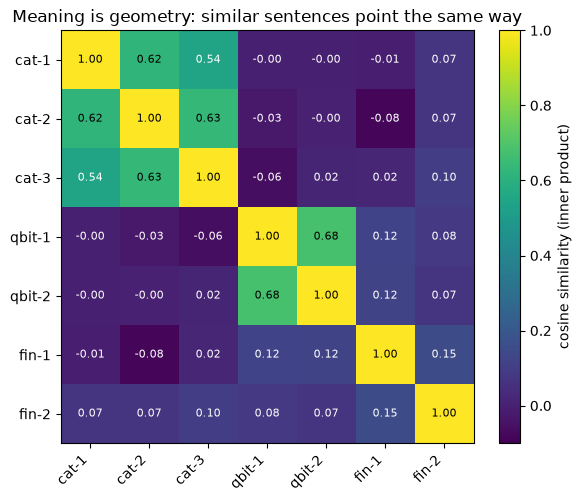

In [3]:
import matplotlib.pyplot as plt

S = E @ E.T            # matrix of inner products = cosine similarities
labels = ['cat-1', 'cat-2', 'cat-3', 'qbit-1', 'qbit-2', 'fin-1', 'fin-2']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(S, cmap='viridis', vmin=-0.1, vmax=1.0)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{S[i,j]:.2f}', ha='center', va='center',
                color='white' if S[i,j] < 0.6 else 'black', fontsize=8)
plt.colorbar(im, label='cosine similarity (inner product)')
ax.set_title('Meaning is geometry: similar sentences point the same way')
plt.tight_layout(); plt.show()

The three topic blocks light up on the diagonal. Meaning that shares no
vocabulary (`cat`/`feline`/`kitten`) is still close **in direction** — that is
what the model learned to encode.

## 4. Semantic search = nearest neighbours by inner product

This is the engine of **Retrieval-Augmented Generation (RAG)**. To find the text
most relevant to a query, embed the query as a vector and rank the documents by
inner product with it. No keyword matching — pure geometry.

In [4]:
def search(query, docs, doc_vecs, k=3):
    q = model.encode([query], normalize_embeddings=True)[0]   # unit vector
    scores = doc_vecs @ q                                     # inner products
    order = np.argsort(-scores)[:k]
    return [(docs[i], float(scores[i])) for i in order]

for q in ['a small sleeping animal', 'how does quantum hardware work']:
    print(f'QUERY: {q!r}')
    for doc, score in search(q, sentences, E):
        print(f'   {score:+.3f}  {doc}')
    print()

QUERY: 'a small sleeping animal'
   +0.446  The feline napped on the carpet.
   +0.368  A kitten rested on the rug.
   +0.291  A cat sat on the mat.

QUERY: 'how does quantum hardware work'
   +0.738  Quantum computers use qubits.
   +0.576  Superposition lets qubits be 0 and 1 at once.
   +0.053  The central bank raised interest rates.



Notice the query words barely overlap the matched sentences — retrieval works
because the *meanings* align as directions. **Unit-normalizing first is what
makes this measure angle (meaning) rather than length** — the exact Lecture 4
lesson, and the most common thing people get wrong when building retrieval.

## 5. A concept is a direction (superposition, revisited)

The Intro lecture described **superposition** as a *linear combination*. Inside an
embedding space, a **concept** behaves the same way: average several examples of
an idea and you get a **direction** that represents it. New text can then be
scored by projecting it onto that direction (an inner product again).

Below we build a 'finance' direction from finance sentences and project every
sentence onto it.

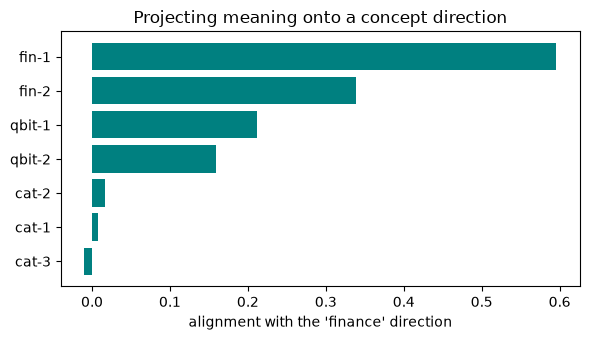

In [5]:
finance_examples = [
    'Interest rates and inflation affect the economy.',
    'Investors traded shares on the exchange.',
]
fin_vecs = model.encode(finance_examples, normalize_embeddings=True)
finance_direction = unit(fin_vecs.mean(axis=0))   # linear combination -> a concept direction

proj = E @ finance_direction                       # project each sentence (inner product)
order = np.argsort(-proj)
plt.figure(figsize=(6, 3.5))
plt.barh([labels[i] for i in order][::-1], proj[order][::-1], color='teal')
plt.xlabel('alignment with the \'finance\' direction')
plt.title('Projecting meaning onto a concept direction')
plt.tight_layout(); plt.show()

The finance sentences score highest — we *measured* an abstract concept with a
dot product. This same move, performed on a model's internal activations, is how
researchers **steer** model behaviour (add a concept direction) and **probe** what
a model represents (read a concept off a direction). See Tier B of
`METHODOLOGY.md`.

## Where this leads

Everything here was Lecture 4 — inner products of unit vectors — applied to
real meaning. From this one operation you can build:

- **semantic search / RAG** (Section 4),
- **clustering, deduplication, and diversity / drift metrics** for model outputs,
- **concept directions** for steering and interpretability (Section 5).

That is the practical bridge from this linear-algebra course to advancing how we
use AI: *meaning is geometry, and you already know the geometry.*

## Exercises

1. Add three sentences of your own on a new topic. Recompute the similarity
   matrix — does your topic form its own block?
2. Re-run Section 3 **without** `normalize_embeddings=True` and compare raw dot
   products to cosine similarities. Why does normalization matter (Lecture 4)?
3. Build a second concept direction (e.g. 'animals') and classify each sentence
   by which direction it aligns with more. You just built a classifier from two
   dot products.
4. Replace the model with a larger one (e.g. `all-mpnet-base-v2`). Do the
   similarities get sharper?
5. Connect to Lecture 11: could you feed these embeddings as input features to
   the variational quantum classifier? What would have to change (hint: qubit
   count vs. embedding dimension, and dimensionality reduction)?